# `sensor` — pixelated silicon slab clustering

`sensor` is an independent toy detector chain (no relation to
`detectorsim2d`'s line/circle tracker): particles fly through a pixelated
silicon slab at some angle — optionally with a constant Lorentz drift —
deposit charge along their path, that charge is digitized onto a pixel
grid, hit pixels are grouped into clusters, and everything is written out
with a matplotlib viewer.

This is the **root producer for the sensor-shaped pipeline**: `splitting`
and `multiplicity` (later notebooks) both consume its `hits`/`clusters`/
`truth`/`contributions` run-directory shape.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from sensor.sim import SimConfig
from sensor.cli import run_simulation
from sensor.vis import plot_event, plot_event_3d, plot_cluster_summary, plot_residual
from sensor.analysis import (
    compute_residuals, cluster_purity,
    dominant_particle_per_cluster, dominant_cluster_per_particle,
)

# Set the theme to the "presentation" style for better visibility in slides
from viz_style import use_theme, PRESENT 
use_theme(PRESENT)

## Simulating a multi-particle run

`SimConfig()` gives documented defaults (150 µm thick, 25x50 µm pixels,
200x200 grid, no drift, one particle per event). Here we turn on Lorentz
drift and ask for 3-particle events, sharing one vertex with independent
opening angles — a small shower, not unrelated single-particle events.


In [2]:
config = SimConfig()
config.n_events = 1000
config.detector.lorentz_slope = 0.0
config.multi.n_particles = 1
config.seed = 7

hits, clusters, truth, contributions = run_simulation(config)
print("hits:", hits.shape, "clusters:", clusters.shape, "truth:", truth.shape, "contributions:", contributions.shape)


hits: (2332, 7) clusters: (1000, 10) truth: (1000, 8) contributions: (2332, 5)


## Viewing one event

`plot_event` draws hit pixels colored by charge, each cluster's bounding
box, and the truth (drift-corrected) charge-collection track for every
particle. `zoom=(nx, ny)` centers a window on the event's largest cluster
rather than showing the full 200x200 grid.


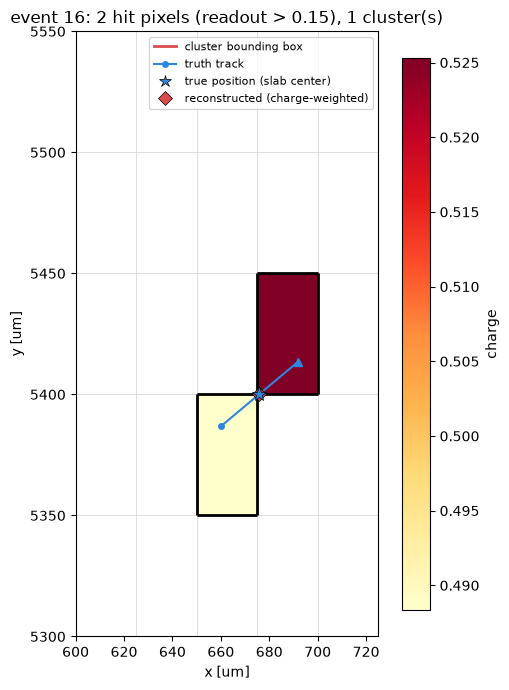

In [3]:
fig = plot_event(hits, clusters, truth, config.detector, event_id=16, zoom=(5, 5), grid=True)


`plot_event_3d` is a presenter-only illustration of *why* a tilted track
leaves charge across more than one pixel: each hit pixel is drawn as a solid
block spanning the slab's full thickness, with the truth tracks crossing it
as straight lines.


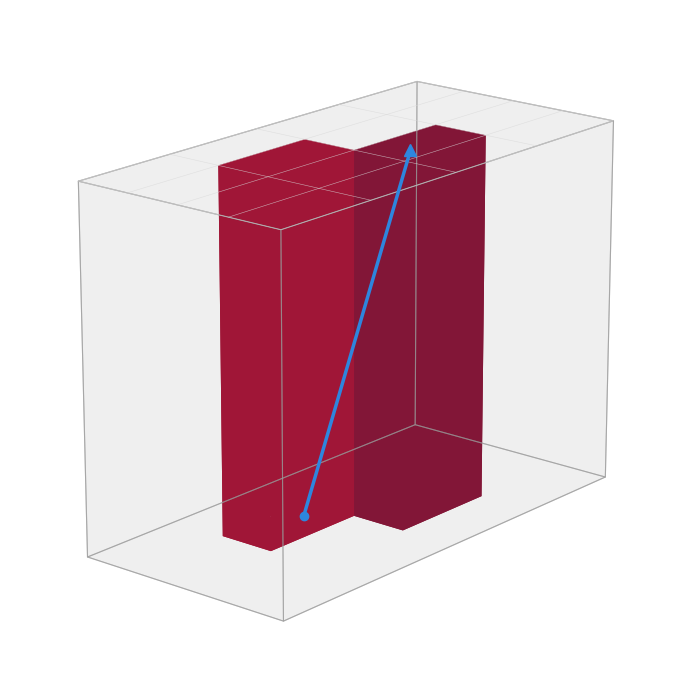

In [4]:
fig = plot_event_3d(hits, truth, config.detector, event_id=16, zoom=(4, 4))


## Cluster-quality summary

`plot_cluster_summary` shows the existing cluster-size/charge-sum
distributions across the whole run.


In [ ]:
fig = plot_cluster_summary(clusters)


## Residuals: reconstructed vs. true position

A truth particle's **true position** is its own trajectory at the sensor's
mid-thickness plane — independent of Lorentz drift, unlike the
drift-corrected track drawn above. `plot_residual`/`compute_residuals` match
each truth particle to its cluster using the *exact* charge-contribution
link in `contributions` whenever available (pass `hits`/`contributions`),
falling back to nearest-centroid-by-position otherwise — the exact link
matters once clusters can merge multiple particles, as here.


In [ ]:
fig = plot_residual(
    clusters, truth, config.detector, types=("charge", "digital"), axis=("x", "y"),
    hits=hits, contributions=contributions,
)


In [ ]:
residuals = compute_residuals(clusters, truth, config.detector, type="charge", hits=hits, contributions=contributions)
print(f"x resolution (charge-weighted centroid): {residuals['residual_x_um'].std():.2f} um")
residuals.head()


## Tracing hits/clusters back to truth particles

Every particle's raw per-pixel charge deposit (before diffusion/noise/
threshold) is kept in `contributions`. With 3-particle showers, clusters
routinely merge more than one truth particle — `cluster_purity` gives the
fraction of each cluster's charge attributable to each contributing
particle; a low fraction flags a merged cluster (exactly what `splitting`,
in the next notebook, tries to undo).


In [ ]:
purity = cluster_purity(hits, contributions)
print(f"mean dominant-particle charge fraction: {purity.groupby(['event_id','cluster_id'])['fraction'].max().mean():.2f}")
purity.head()


In [ ]:
dominant = dominant_particle_per_cluster(hits, contributions)
dominant.head()


## Gotchas recap

- Three *independent* thresholds shape the pipeline:
  `digitization.threshold` (noise floor, decides if a pixel becomes a `hits`
  row at all), `readout_threshold` (drops pixels **before clustering**,
  shapes `clusters`/residuals/cluster-size), and `visualize`'s
  `--readout-threshold` (display-only, doesn't touch stored data). For
  analysis, bake the cut into `SimConfig.readout_threshold`, not the viz
  flag.
- `contributions` is exact only when `diffusion_sigma_um == 0` (the
  default) — noise is never attributable to any particle.
- `clusters` always carries **two parallel centroids**:
  `x/y_centroid_um` (charge-weighted) and `x/y_centroid_digital_um`
  (unweighted digital mean).
